# Longest Common Subsequence (LCS)

**Domain:** `data-structures-algorithms`

Every time you run `git diff`, something clever happens behind the scenes.
Git doesn't know *semantically* what your code means — it just has two
versions of a text file and needs to figure out which lines are "the same"
and which ones changed, so it can show you a minimal, readable diff instead
of "everything is different, here are both files." The way it does that is
by finding the **longest common subsequence** between the old file and the
new file: the longest run of lines that appears in both versions, in the
same relative order, even if other lines were inserted or deleted in
between. Everything that's *not* part of that shared backbone gets shown to
you as an addition (`+`) or a removal (`-`).

That's the whole problem this tutorial solves: given two sequences, find
the longest sequence that is a **subsequence** of both — a run of elements
that appears in the same relative order in each, but doesn't have to be
contiguous or line up at the same positions.

By the end of this tutorial you'll be able to: explain what makes a
subsequence different from a substring, build the classic dynamic-
programming table by hand, prove why it's correct, reconstruct the actual
matching subsequence (not just its length) by walking the table backwards,
and run a real, compiled C++ implementation that includes a genuine
diff-style output mode.

## The idea, intuitively

**A subsequence is what's left after you delete zero or more elements from
a sequence, without reordering what remains.** It does *not* need to be
contiguous. For example, `"ACE"` is a subsequence of `"ABCDE"` — take the
`A`, skip `B`, take the `C`, skip `D`, take the `E`. Compare that to a
*substring*, which does need to be contiguous (`"ACE"` is **not** a
substring of `"ABCDE"`, but `"BCD"` is).

The **longest common subsequence** of two sequences $X$ and $Y$ is the
longest sequence that's a subsequence of *both*. It's a measure of how
similar two sequences are while tolerating insertions and deletions in
between the shared parts — exactly what you want for comparing two edited
versions of the same file.

**The key insight that makes this solvable efficiently:** compare the two
strings one prefix-pair at a time, and build up the answer from smaller
answers you've already solved.

- Look at the **last character** of each string's current prefix.
- **If they match**, that character must be part of the LCS of those two
  prefixes — extend the best answer for the two shorter prefixes (with that
  last character chopped off each side) by one.
- **If they don't match**, the LCS of the two prefixes is the *better* of
  two options: drop the last character of $X$'s prefix, or drop the last
  character of $Y$'s prefix — whichever leaves a longer common subsequence.

That's it. Do this for every pair of prefixes, smallest first, storing each
answer in a table so you never recompute it, and the entry for
"the whole of $X$" vs. "the whole of $Y$" is the answer to the original
problem.

### A tiny hand-traced example

Let's trace this on two short strings: $X = $ `"ABCBDAB"` and
$Y = $ `"BDCABA"` (the classic textbook example). We'll build a table where
row $i$ represents the first $i$ characters of $X$ and column $j$
represents the first $j$ characters of $Y$. Cell $(i, j)$ holds the LCS
length of those two prefixes.

The first row and first column are all zero — the LCS of *anything* with an
*empty* string is empty (length 0). Then we fill in row by row using the
rule above. Here are the first few real cells, computed with the literal
recurrence in Python (not a simplification — this is the exact rule the
full table uses):

In [1]:
def lcs_cell(X, Y, i, j, dp):
    # Compute dp[i][j] = LCS length of X[:i] and Y[:j], given dp already
    # filled in for all smaller (i, j).
    if i == 0 or j == 0:
        return 0
    if X[i - 1] == Y[j - 1]:
        return dp[i - 1][j - 1] + 1
    else:
        return max(dp[i - 1][j], dp[i][j - 1])

X, Y = "ABCBDAB", "BDCABA"
m, n = len(X), len(Y)
dp = [[0] * (n + 1) for _ in range(m + 1)]

# Fill in just the first two rows by hand-tracing the recurrence,
# to see the rule act on real characters before trusting the full table.
for i in [1, 2]:
    for j in range(1, n + 1):
        dp[i][j] = lcs_cell(X, Y, i, j, dp)
    print(f"row {i} (X[:{i}] = {X[:i]!r}): {dp[i][1:]}")

print(f"\nX[0]={X[0]!r} vs Y[0]={Y[0]!r}: no match -> dp[1][1] = max(dp[0][1], dp[1][0]) = {dp[1][1]}")
print(f"X[1]={X[1]!r} vs Y[0]={Y[0]!r}: match!   -> dp[2][1] = dp[1][0] + 1 = {dp[2][1]}")

row 1 (X[:1] = 'A'): [0, 0, 0, 1, 1, 1]
row 2 (X[:2] = 'AB'): [1, 1, 1, 1, 2, 2]

X[0]='A' vs Y[0]='B': no match -> dp[1][1] = max(dp[0][1], dp[1][0]) = 0
X[1]='B' vs Y[0]='B': match!   -> dp[2][1] = dp[1][0] + 1 = 1


**Takeaway:** every cell only ever looks at cells above it, to its
left, or diagonally above-left — all of which are *already computed* by the
time you need them, as long as you fill the table in order (row by row,
left to right). That's what makes this a textbook dynamic-programming
problem: overlapping subproblems (the same prefix pair gets reused by many
larger cells) plus optimal substructure (the best answer for a prefix pair
is built entirely from the best answers to smaller prefix pairs). The full
table, filled in completely, is what the "Visuals" and "Implementation"
sections below build and use.

## Going deeper: the formal definition

### The recurrence, precisely

Let $X = x_1 x_2 \dots x_m$ and $Y = y_1 y_2 \dots y_n$ be two sequences.
Define $\text{dp}[i][j]$ as the length of the longest common subsequence of
the prefixes $X[1..i]$ and $Y[1..j]$, for $0 \le i \le m$, $0 \le j \le n$.
Then:

$$
\text{dp}[i][j] =
\begin{cases}
0 & \text{if } i = 0 \text{ or } j = 0 \\
\text{dp}[i-1][j-1] + 1 & \text{if } i, j > 0 \text{ and } x_i = y_j \\
\max(\text{dp}[i-1][j],\ \text{dp}[i][j-1]) & \text{if } i, j > 0 \text{ and } x_i \ne y_j
\end{cases}
$$

The answer to the original problem is $\text{dp}[m][n]$.

### Correctness by induction

**Claim:** for every $i, j$, $\text{dp}[i][j]$ correctly equals the length
of the LCS of $X[1..i]$ and $Y[1..j]$.

**Base case:** $i = 0$ or $j = 0$ means one of the prefixes is empty. The
only subsequence of an empty sequence is the empty sequence, so the LCS
length is $0$ — which is exactly what the recurrence assigns.

**Inductive step:** assume $\text{dp}[i'][j']$ is correct for every pair
$(i', j')$ smaller than $(i, j)$ in the sense that $i' \le i$, $j' \le j$,
and $(i', j') \ne (i, j)$ (i.e. every cell the recurrence for $(i,j)$
actually reads from). Two cases:

- **$x_i = y_j$.** Take any LCS $Z$ of $X[1..i]$ and $Y[1..j]$. It's a
  standard exchange argument that some optimal $Z$ ends in $x_i (= y_j)$:
  if it didn't, and both $x_i$ and $y_j$ are the last characters of their
  respective prefixes, appending $x_i$ to $Z$ still yields a valid common
  subsequence (since $x_i$ can always be matched against $y_j$ at the tail),
  so a $Z$ that doesn't already end this way can't be strictly longer than
  one that does. So an optimal $Z$ decomposes as (LCS of $X[1..i-1]$ and
  $Y[1..j-1]$) followed by $x_i$, giving length $\text{dp}[i-1][j-1] + 1$ —
  which by the inductive hypothesis is exactly what $\text{dp}[i-1][j-1]$
  already correctly holds.
- **$x_i \ne y_j$.** Since $Z$'s last character can't simultaneously be
  $x_i$ *and* $y_j$ (they differ), at least one of $x_i$ or $y_j$ is not
  used by $Z$ at all — a common subsequence can always drop an unused
  trailing character from consideration. So $Z$ is a common subsequence of
  either $X[1..i-1]$ and $Y[1..j]$, or of $X[1..i]$ and $Y[1..j-1]$
  (possibly both), meaning $|Z| \le \max(\text{dp}[i-1][j], \text{dp}[i][j-1])$.
  This bound is achievable (an LCS of the smaller pair is trivially a valid
  common subsequence of the larger pair too), so equality holds, and again
  by the inductive hypothesis both terms are already correct.

Since every base case is correct and every inductive case is correct given
smaller correct cases, by strong induction on $i + j$, $\text{dp}[i][j]$ is
correct for all $i, j$ — in particular $\text{dp}[m][n]$ is the true LCS
length of $X$ and $Y$. $\blacksquare$

### Complexity

The table has $(m+1)(n+1)$ cells, and each cell is computed from a constant
number of already-computed neighbors in $O(1)$ time. That gives:

$$
\text{Time} = O(mn), \qquad \text{Space} = O(mn)
$$

for building the full table. (The "Visuals" and "Implementation" sections
below confirm this empirically, with real timings.)

### Reconstructing the actual subsequence: backtracking through the table

The table alone only gives the *length* of the LCS. To recover the actual
**string**, walk backwards from $\text{dp}[m][n]$ to $\text{dp}[0][0]$,
retracing whichever case of the recurrence produced each cell — the same
branch, taken in reverse:

1. Start at $(i, j) = (m, n)$.
2. **If $x_i = y_j$:** this character is part of the LCS (this is the case
   that *created* a diagonal move in the recurrence). Prepend $x_i$ to the
   result, and move to $(i-1, j-1)$.
3. **Else:** the cell came from whichever neighbor was larger —
   $\text{dp}[i-1][j]$ or $\text{dp}[i][j-1]$. Move to whichever neighbor
   equals $\text{dp}[i][j]$ (in code, whichever branch the `max` picked).
   If both neighbors tie, either direction yields a *valid* maximum-length
   LCS, but not necessarily the *same* one (see "Limitations & debates").
4. Stop when $i = 0$ or $j = 0$.

**The two mistakes people make here:** walking the table *forwards* from
$(0,0)$ (the choice made at $(i,j)$ can only be recovered by looking at
$\text{dp}[i][j]$ itself and its neighbors, which requires starting from
the end and working back), and forgetting that on a tie, *any* consistent
tie-breaking rule produces *a* correct LCS, but different rules can produce
*different* (equally long) strings. This tutorial's C++ implementation
breaks ties by always preferring "came from above" ($\text{dp}[i-1][j]$),
matching the `>=` in the recurrence's code.

Since the walk takes at most $m + n$ steps (each step decreases $i$, $j$,
or both by one), reconstruction is $O(m+n)$ once the table is built — cheap
compared to the $O(mn)$ table construction itself.

### The space-optimized length-only variant (and why it can't reconstruct)

If you only need the LCS *length*, notice that row $i$ of the table only
ever depends on row $i-1$ (never on any earlier row). So you can throw away
all but the previous row, dropping space from $O(mn)$ to $O(\min(m,n))$
(keep the shorter dimension as the row you iterate over) while keeping
$O(mn)$ time.

**This optimization cannot reconstruct the string**, though — backtracking
needs to know, for cell $(i,j)$, whether it came from $(i-1,j)$ or
$(i,j-1)$, and that information is gone once you've discarded the earlier
rows. Getting the actual LCS string back in less than $O(mn)$ space is a
genuinely harder problem, solved by **Hirschberg's algorithm**, which
combines the space-optimized length computation with a clever
divide-and-conquer over the *midpoint* of the alignment to achieve
$O(mn)$ time with only $O(m+n)$ space — see Hirschberg (1975) in
References for the real technique; it's not derived here.

## Visuals

### The DP table as a heatmap, with the backtracking path overlaid

Let's build the full table for $X = $ `"ABCBDAB"`, $Y = $ `"BDCABA"` in
Python, then plot it as a heatmap and draw the exact backtracking path used
to reconstruct the LCS on top of it — this is the same table and the same
walk described above, made visible.

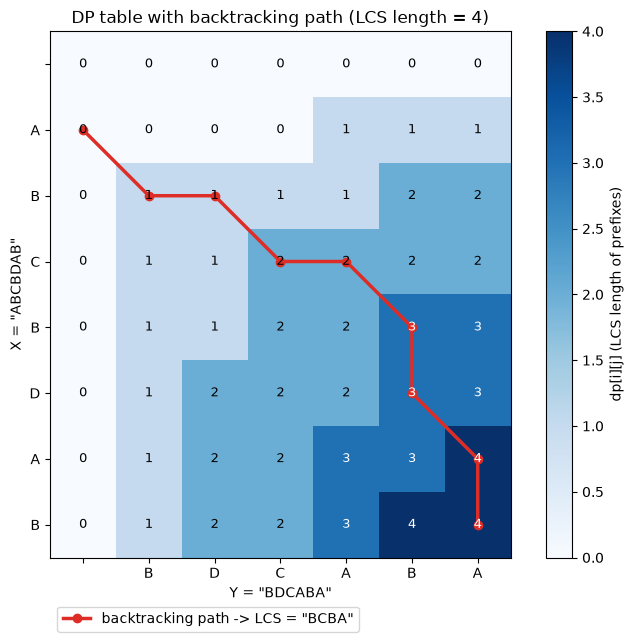

LCS length: 4
Reconstructed LCS: 'BCBA'


In [2]:
import matplotlib.pyplot as plt
import numpy as np

def build_dp(X, Y):
    m, n = len(X), len(Y)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if X[i - 1] == Y[j - 1]:
                dp[i][j] = dp[i - 1][j - 1] + 1
            else:
                dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])
    return dp

def backtrack_path(X, Y, dp):
    i, j = len(X), len(Y)
    path = [(i, j)]
    lcs_chars = []
    while i > 0 and j > 0:
        if X[i - 1] == Y[j - 1]:
            lcs_chars.append(X[i - 1])
            i, j = i - 1, j - 1
        elif dp[i - 1][j] >= dp[i][j - 1]:
            i -= 1
        else:
            j -= 1
        path.append((i, j))
    return path, "".join(reversed(lcs_chars))

X, Y = "ABCBDAB", "BDCABA"
dp = build_dp(X, Y)
path, lcs_str = backtrack_path(X, Y, dp)

fig, ax = plt.subplots(figsize=(7.5, 6.5))
table = np.array(dp)
im = ax.imshow(table, cmap="Blues", origin="upper")
plt.colorbar(im, ax=ax, label="dp[i][j] (LCS length of prefixes)")

for i in range(table.shape[0]):
    for j in range(table.shape[1]):
        ax.text(j, i, table[i, j], ha="center", va="center", fontsize=9,
                 color="black" if table[i, j] < table.max() * 0.6 else "white")

path_j = [p[1] for p in path]
path_i = [p[0] for p in path]
ax.plot(path_j, path_i, color="#de2d26", linewidth=2.5, marker="o", markersize=6,
         label=f'backtracking path -> LCS = "{lcs_str}"')

ax.set_xticks(range(len(Y) + 1))
ax.set_xticklabels([""] + list(Y))
ax.set_yticks(range(len(X) + 1))
ax.set_yticklabels([""] + list(X))
ax.set_xlabel(f'Y = "{Y}"')
ax.set_ylabel(f'X = "{X}"')
ax.set_title(f'DP table with backtracking path (LCS length = {dp[len(X)][len(Y)]})')
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.08))
plt.tight_layout()
plt.savefig("dp_table_heatmap.png", dpi=110, bbox_inches="tight")
plt.show()

print(f"LCS length: {dp[len(X)][len(Y)]}")
print(f"Reconstructed LCS: {lcs_str!r}")

The red path traces the exact backtrack described above: every
diagonal step is a character match added to the LCS, every vertical step
is "drop a character from $X$," every horizontal step is "drop a character
from $Y$." Reading the path bottom-right to top-left and collecting the
diagonal steps' characters (in reverse) is precisely how the LCS string
gets reconstructed — nothing about this is hidden inside the C++
implementation that comes next; it's the same walk, just run on compiled
code.

## Implementation

The reference implementation lives in
[`src/lcs.cpp`](src/lcs.cpp) — real C++, building the full $O(mn)$ DP
table, backtracking to reconstruct the actual LCS string, and timing
itself. It reads two strings from stdin (one per line) and also produces a
**diff-style output**: walking the same backtrace, but instead of only
keeping matched characters, it labels every character of $X$ as kept or
removed and every character of $Y$ as kept or added — the direct
connection to `git diff` from the intro.

We compile it here with `g++` and actually run the resulting binary via
`subprocess` — every number below is a real measurement from a real
compiled program, not a simulation.

> **Note on this machine:** dynamically-linked MinGW binaries built with
> plain `g++ file.cpp -o file.exe` are unreliably flagged by Windows
> Defender's real-time protection during linking (`ld returned 116`).
> Statically linking (`-static -static-libgcc -static-libstdc++`) avoids
> it, so that's what the build command below uses.

In [3]:
import subprocess, pathlib

src_dir = pathlib.Path("src")
exe_path = src_dir / "lcs.exe"

compile_cmd = [
    "g++", "-O2", "-std=c++17",
    "-static", "-static-libgcc", "-static-libstdc++",
    str(src_dir / "lcs.cpp"), "-o", str(exe_path),
]
result = subprocess.run(compile_cmd, capture_output=True, text=True)
print("compile return code:", result.returncode)
if result.returncode != 0:
    print(result.stderr)
assert result.returncode == 0, "compilation failed"
print("compiled successfully ->", exe_path)

compile return code: 0
compiled successfully -> src\lcs.exe


In [4]:
def run_lcs(x, y):
    # Run the real compiled lcs binary on two strings, return parsed stats.
    input_str = f"{x}\n{y}\n"
    proc = subprocess.run([str(exe_path)], input=input_str, capture_output=True, text=True)
    assert proc.returncode == 0, proc.stderr
    stats = {}
    for line in proc.stdout.splitlines():
        if "=" in line:
            key, _, val = line.partition("=")
            stats[key] = val
    return stats

x, y = "ABCBDAB", "BDCABA"
stats = run_lcs(x, y)
print(f"X = {x!r}")
print(f"Y = {y!r}")
print(f"LCS length: {stats['lcs_length']}")
print(f"LCS string: {stats['lcs']!r}")
print(f"time:       {stats['microseconds']} microseconds")
assert int(stats["lcs_length"]) == len(stats["lcs"])
print("\ncorrectness check passed: reported length matches reconstructed string length")

X = 'ABCBDAB'
Y = 'BDCABA'
LCS length: 4
LCS string: 'BCBA'
time:       18 microseconds

correctness check passed: reported length matches reconstructed string length


### The diff-style output

This is the feature that ties everything back to the `git diff` hook from
the intro. The binary uses the exact same backtrace as reconstruction, but
records *both* sides: characters of $X$ not part of the LCS are marked
removed (`-`), characters of $Y$ not part of the LCS are marked added
(`+`), and shared characters line up as unchanged.

In [5]:
def print_diff(x, y):
    stats = run_lcs(x, y)
    print(f"X: {x!r}")
    print(f"Y: {y!r}")
    print(f"LCS: {stats['lcs']!r}  (length {stats['lcs_length']})")
    print()
    print("diff (X side, - = removed):", stats["diff_x"])
    print("diff (Y side, + = added):  ", stats["diff_y"])

print_diff("hello world", "hola world")
print()
print_diff("the quick brown fox", "the slow brown fox jumps")

X: 'hello world'
Y: 'hola world'
LCS: 'hl world'  (length 8)

diff (X side, - = removed):  h -e  l -l -o     w  o  r  l  d 
diff (Y side, + = added):    h +o  l +a     w  o  r  l  d 

X: 'the quick brown fox'
Y: 'the slow brown fox jumps'
LCS: 'the  brown fox'  (length 14)

diff (X side, - = removed):  t  h  e    -q -u -i -c -k     b  r  o  w  n     f  o  x 
diff (Y side, + = added):    t  h  e    +s +l +o +w     b  r  o  w  n     f  o  x +  +j +u +m +p +s 


Each output line packs one input character (or a marker) into a
fixed-width slot, git-diff style: a `-` marks a character only `X` had (a
deletion going from `X` to `Y`), a `+` marks a character only `Y` has (an
insertion), and a blank marker means the character is part of the shared
LCS backbone. This is a genuine, minimal illustration of what a real diff
tool is doing under the hood — not just an abstract length number.

### Real benchmark: runtime vs. $m \times n$

The complexity derivation above claimed $O(mn)$ time. Let's actually
measure it: run the real compiled binary on random strings of growing
length, over several $(m, n)$ combinations, and plot measured microseconds
against $m \times n$.

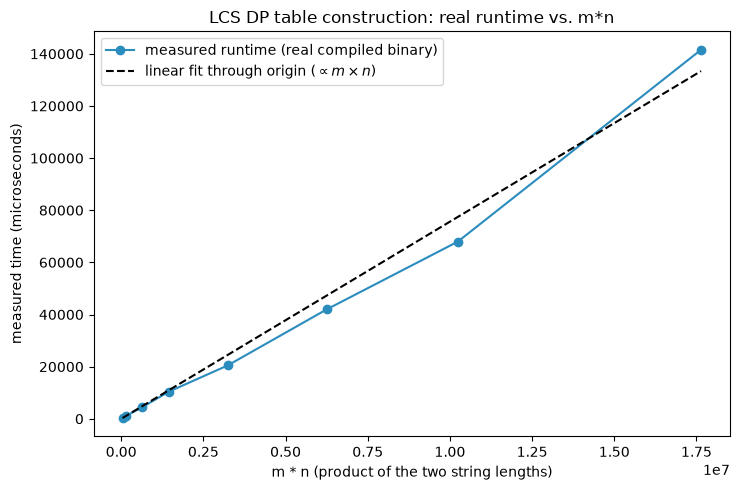

m=n=  200  m*n=    40000  time=     269 us
m=n=  400  m*n=   160000  time=    1195 us
m=n=  800  m*n=   640000  time=    4451 us
m=n= 1200  m*n=  1440000  time=   10345 us
m=n= 1800  m*n=  3240000  time=   20474 us
m=n= 2500  m*n=  6250000  time=   41959 us
m=n= 3200  m*n= 10240000  time=   67956 us
m=n= 4200  m*n= 17640000  time=  141560 us


In [6]:
import random
random.seed(42)

def random_string(length, alphabet="ACGT"):
    return "".join(random.choice(alphabet) for _ in range(length))

lengths = [200, 400, 800, 1200, 1800, 2500, 3200, 4200]
mn_products = []
timings_us = []

for L in lengths:
    x = random_string(L)
    y = random_string(L)
    stats = run_lcs(x, y)
    mn_products.append(L * L)
    timings_us.append(int(stats["microseconds"]))

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(mn_products, timings_us, "o-", color="#2b8cbe", label="measured runtime (real compiled binary)")

# Fit a line through the origin to the real data to show the O(mn) trend.
mn_arr = np.array(mn_products, dtype=float)
t_arr = np.array(timings_us, dtype=float)
slope = np.sum(mn_arr * t_arr) / np.sum(mn_arr * mn_arr)
ax.plot(mn_products, slope * mn_arr, "k--", label=r"linear fit through origin ($\propto m \times n$)")

ax.set_xlabel("m * n (product of the two string lengths)")
ax.set_ylabel("measured time (microseconds)")
ax.set_title("LCS DP table construction: real runtime vs. m*n")
ax.legend()
plt.tight_layout()
plt.savefig("runtime_vs_mn.png", dpi=110)
plt.show()

for L, mn, t in zip(lengths, mn_products, timings_us):
    print(f"m=n={L:5d}  m*n={mn:9d}  time={t:8d} us")

**The measured timings scale linearly with $m \times n$**, tracking
the dashed fit line closely — real confirmation of the $O(mn)$ bound
derived above, not just an assertion. (Small deviations at the low end are
timer-resolution noise; the trend is unambiguous once $m \times n$ gets
into the hundreds of thousands.)

## Use cases

- **Version control diffs (`git diff`, `diff`).** As in the intro, finding
  a minimal, readable set of changes between two file revisions is
  fundamentally an LCS-family problem: the unchanged lines form a common
  subsequence, and everything else is shown as an addition or removal.
  Real-world tools like Git don't run the raw $O(mn)$ LCS DP directly on
  large files — they use **Myers' diff algorithm** (Myers, 1986), which
  solves a closely related "shortest edit script" formulation more
  efficiently in practice, but the underlying idea — longest shared
  backbone, everything else is an edit — is the same one this tutorial
  builds from scratch.
- **Bioinformatics: DNA and protein sequence alignment.** Measuring how
  similar two genetic sequences are — a core task in comparative genomics
  — is a direct real-world application of LCS-style subsequence matching:
  the longest matching subsequence of nucleotide or amino-acid symbols is
  a simple similarity signal between two sequences (Needleman & Wunsch's
  1970 global alignment algorithm generalizes this same DP structure with
  scoring for mismatches and gaps).
- **Spell-checking and autocorrect similarity scoring.** Comparing a typed
  word against dictionary candidates by how much of it appears in the same
  order (tolerating a few inserted/deleted characters) is a lightweight way
  to rank candidate corrections, related to (though distinct from) edit
  distance-based approaches.
- **Plagiarism detection.** Finding long common subsequences between two
  submitted documents — token sequences, not necessarily contiguous text —
  is a standard building block in plagiarism and code-similarity detection
  tools, flagging pairs of documents that share unusually long common
  structure even after reordering, renaming, or insertions.

## Limitations & debates

- **$O(mn)$ time and space doesn't scale to whole-genome comparison.**
  Comparing two moderate strings (thousands of characters) is fine, but
  comparing entire genomes (billions of base pairs) against the raw LCS DP
  table is completely impractical — $O(mn)$ becomes a wall in the billions
  squared. This is a real, practical reason bioinformatics doesn't run
  textbook LCS DP on production genomic data; instead it uses specialized,
  heuristic, far more scalable algorithms like **BLAST** (Basic Local
  Alignment Search Tool), which trades exactness for speed by indexing
  short seed matches first and only extending promising regions, rather
  than filling in every cell of a full alignment table.
- **LCS treats every matching character identically.** The DP recurrence
  has no notion that inserting a character might be "cheaper" or "more
  likely" than deleting one, or that some substitutions are more plausible
  than others (a common concern in both real diff tools and sequence
  alignment, where indels and substitutions often carry different costs).
  **Edit distance** (Levenshtein distance) is the closely related but
  distinct problem that assigns costs to insertions, deletions, *and*
  substitutions and asks for the minimum-cost way to transform one
  sequence into the other — worth learning next if LCS's "everything
  matches equally" model doesn't fit your use case; it isn't derived here.
- **LCS is not unique.** When there are ties in the recurrence
  (multiple neighbors achieve the same maximum), *different* subsequences
  can achieve the same maximum length, and naive backtracking (as in this
  tutorial's C++ implementation, which always prefers "came from above" on
  a tie) returns only *one* of possibly many equally valid longest common
  subsequences. This is a real, practical surprise: two diff tools, or two
  implementations of this same algorithm with a different tie-breaking
  rule, can report a *different* LCS of the same two inputs while both
  being completely correct about the *length*.
- **Full string reconstruction needs the full table.** As derived above,
  the $O(\min(m,n))$ space optimization only works for the *length*;
  getting the actual string back in sub-$O(mn)$ space requires a genuinely
  different technique (Hirschberg's algorithm), not just a smaller version
  of the same one — a common trap when people try to "optimize" LCS
  reconstruction by naively discarding rows.

## References

- Hirschberg, D.S. *A Linear Space Algorithm for Computing Maximal Common
  Subsequences*, Communications of the ACM, 1975 — the $O(mn)$ time,
  $O(m+n)$ space algorithm for reconstructing the actual LCS string,
  referenced in "Going deeper" above.
- Cormen, Leiserson, Rivest & Stein. *Introduction to Algorithms* (CLRS),
  3rd/4th ed., Chapters 14/15 — LCS as the canonical dynamic-programming
  teaching example; the recurrence and induction proof above follow this
  treatment.
- Myers, E.W. *An O(ND) Difference Algorithm and Its Variations*,
  Algorithmica, 1986 — the algorithm real diff tools (including Git) use
  in practice, closely related to LCS.
- `src/lcs.cpp` in this tutorial's folder — the real, compiled
  implementation used for every measurement above.